# MC model of particle motion on crystal surface

Simulate particle motion on a 100x100 grid with periodic boundary conditions. Simulate particle position as "value" in a 2D field. Allowed jumps are left, right, up, and down with equal probability. Calculate 100000 steps. Choose the initial position in the center.

Calculate the probability of occupation of individual grid points. This requires an extra grid for statistics, where you will accumulate the number of steps during which the cell was occupied. Draw a density map.

How many steps did the particle spend at most and at least in one cell? Does this correspond to the Poisson distribution?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randint
from numba import njit

In [2]:
FREE = 0
PARTICLE = 1
CRYSTAL = 2

N = 100
grid = np.zeros((N, N), dtype=np.int16)

In [3]:
def move_particle(grid, i, j):
    M, N = grid.shape
    direction = [
        [-1, 0],
        [1, 0],
        [0, -1],
        [0, 1],
    ][randint(4)]
    
    i1 = (i + direction[0]) % M
    j1 = (j + direction[1]) % N
    
    if grid[i1, j1] == FREE:
        grid[i1, j1] = PARTICLE
        grid[i, j] = FREE

In [4]:
def move_particles(grid):
    iis, jjs = np.where(grid==PARTICLE)
    for i, j in zip(iis, jjs):
        move_particle(grid, i, j)

In [5]:
niter = 100000
grid = np.zeros((N, N), dtype=np.int16)
gridsum = grid.copy()

grid[N//2, N//2] = PARTICLE
for i in range(niter):
    move_particles(grid)
    gridsum += grid

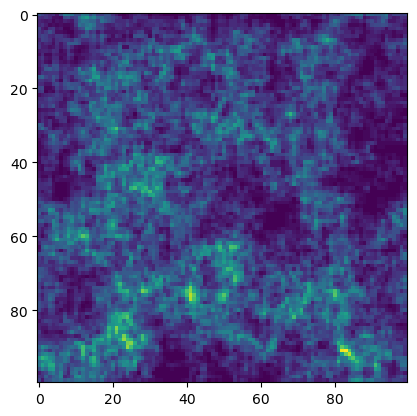

In [6]:
plt.imshow(gridsum)

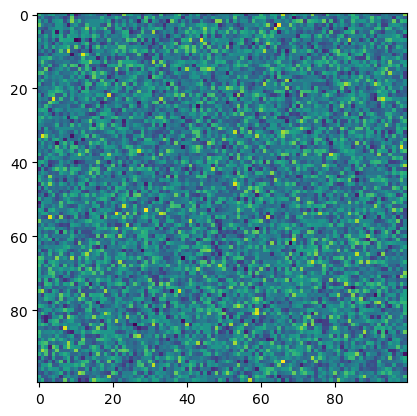

In [7]:
mu = niter/(N*N)
plt.imshow(np.random.poisson(mu, size=(N, N)))

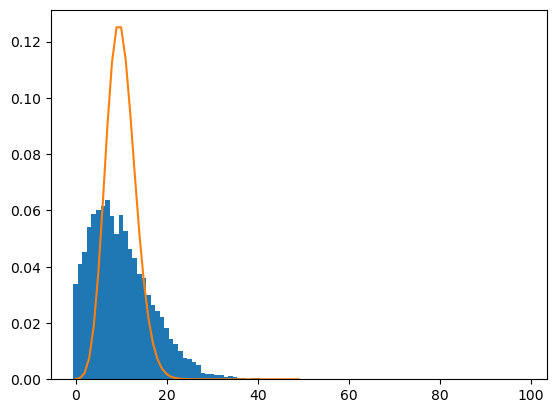

In [8]:
plt.hist(gridsum.ravel(), bins=np.arange(100)-0.5, density=True)
from scipy.stats import poisson
mu = niter/(N*N)
X = np.arange(0, int(mu*5))
plt.plot(X, poisson.pmf(X, mu))

The particle positions form a Markov chain. They are not independent and the distribution of positions does not have Poisson distribution on short time scales.

## MC credit task option 2:

Simulate "crystallization". If the particle has at least 1 neighbor, it cannot move anymore. Add a new particle every 100 steps. Simulate 100000 steps in total.

Alternatively, you can simulate growth from a fixed crystallization nucleus in the middle of the work area.

Possible further experiments: alternative definition of neighbors (e.g. diagonally); non-zero probability of movement of the "crystallized" particle (e.g. depending on the number of neighbors)

In [57]:
from numpy.random import randint
def add_particle(grid):
    """Find random free position on the grid and add particle there"""

def has_neighbors_any(grid, i, j):
    """Return True if any neighborin cell to [i,j] is occupied"""

def has_neighbors_crystal(grid, i, j):
    """Return True if any neighborin cell to [i,j] is CRYSTAL"""

def crystallize_particles(grid, has_neighbors=has_neighbors_any):
    """Change all particles with a neighbor to CRYSTAL"""
